Classification models

- Reducing revenue loss due to cancellations
  - Achieved by predicting cancellations and intervene with deals    and incentives (classification)

---------------------------------------------------------------------------------

Classification is a supervised machine learning method where the model attempts to predict class of a label based on selected features.

The label that will be predicted is the is_canceled label to predict the rate of cancellation due to the selected variables and see how to reduce the rate of cancellation to increase revenue.

The select variables are:
- days_in_waiting_list - which explains how many days a booking was in the waiting list before it was confirmed to the customer. This metric emphaises how efficency has an impact on the rate of cancellations

-------------------------------------------------------------------------------

The procesed used to model and evaluate is as follows:
1. Load necessary libraries
2. Identify the target (cancellations)
3. Feature engineer (may not be required)
4. Encode categorical variables (may not be required)
5. Split the data
6. Train the model
7. Evaluate the model

The three selected models are:
- Logistic Regression - model calculates a the propbability of an event occuring by transforming a linear combination of input variables into a sigmoid (s-curve)
- Decision Tree Regressor - the model builds a tree like prediction model based on the x variables to predict the propbability of a cancelation occuring.
- Kneighbours - it considers the proximity that data points have to each other. KNN predicts if a cancellation will occur if a data point lies close to a varible that is cancellation prone or close to a variable that is not.

---------------------------

1. Load necessary libraries

In [2]:
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder  

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.neighbors import KNeighborsClassifier

In [3]:
data = pd.read_csv('hotel_bookings.csv')

Quick data cleansing

In [132]:
data = data.drop(columns=['company'])
data['agent'] = data['agent'].fillna('Not Listed')
data['country'] = data['country'].fillna('Not Listed')

3. Encoding

In [23]:
# Dictionary mapping month to season
season_map = {
    "December": "Winter", "January": "Winter", "February": "Winter",
    "March": "Spring", "April": "Spring", "May": "Spring",
    "June": "Summer", "July": "Summer", "August": "Summer",
    "September": "Autumn", "October": "Autumn", "November": "Autumn"
}

# Create the season column
data["season"] = data["arrival_date_month"].map(season_map)

# ONE-HOT ENCODING NON-ORDINAL CATEGORICAL VARIABLES
non_ordinal_categorical_data = data[["season"]]


# Reduced quantity of variables to reduce possibility of overfitting

ohe = OneHotEncoder(sparse_output=False)
encoded_season= ohe.fit_transform(non_ordinal_categorical_data)
print("Original:\n", non_ordinal_categorical_data)
print("One-Hot Encoded:\n", encoded_season)

Original:
         season
0       Summer
1       Summer
2       Summer
3       Summer
4       Summer
...        ...
119385  Summer
119386  Summer
119387  Summer
119388  Summer
119389  Summer

[119390 rows x 1 columns]
One-Hot Encoded:
 [[0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 ...
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]]


5. Splitting the data

In [4]:
X = data['days_in_waiting_list'].values.reshape(-1, 1)
y = data['is_canceled']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

6. Train the model

Model 1: Logistic Regression

In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


7. Evaluation

              precision    recall  f1-score   support

           0       0.63      0.99      0.77     15033
           1       0.51      0.01      0.02      8845

    accuracy                           0.63     23878
   macro avg       0.57      0.50      0.40     23878
weighted avg       0.59      0.63      0.49     23878



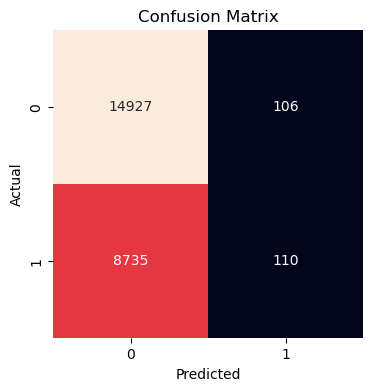

In [6]:
preds = model.predict(X_test)
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

The confusion matrix states the performance of the classifier, which is then used to calculate the precision recall ect. 

The confusion matrix is stating the following:

- False Negatives (Actual = 0, Predicted = 0) = 15,013
- False positives (Actual = 0, Predicted = 1) =20
- True Negatives(Actual = 1, Predicted = 0) = 5995
- True positive(Actual = 1, Predicted = 1) = 2850

- Precision - measures postitive prediction accuracy
- Recall - measures true positive detection
- f1-score - a harmonic mean between precision and recall
- support - the count of instances per class
- accuracy - the overall correctness of the model
- macro avg - gives equal unweighted mean to each class' metric (recall, precision ect)
- weighted average - weighs each classes metric by the support. making it more represenative of the data, especially if its imbalanced

Text(0, 0.5, 'True Positive Rate')

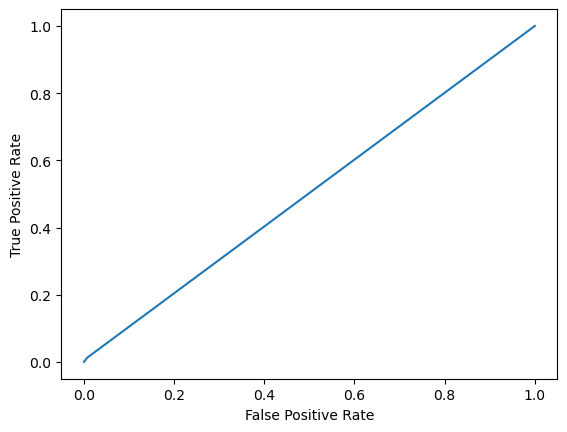

In [7]:
def plot_roc_curve(y_test, preds):
    """
    plots the roc curve based of the probabilities
    """

fpr, tpr, thresholds = roc_curve(y_test, preds)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

The roc curve is a graph the illustrates how well the model can distinguish between postive and negative classes. The graph begins to arch at 0.01 indicating 0.01 is the optimal threshold to classify the outcome/ efficiency of the model reduces beyond 0.0.01TP.

calculating actual tp

In [125]:
2850/(2850+15013+20+5995)

0.11935673004439233

The area under the curve (auc) is calculated from this graph and outputs whether the models perfomanmce is acceptable or not

In [8]:
plot_roc_curve(y_test, preds)
print(f'model 1 AUC score: {roc_auc_score(y_test, preds)}')

model 1 AUC score: 0.5026926253104298


The area under the curve score highlights that the model has acceptable discrimination as it has between 0.6-0.8

In [9]:
probs = model.predict_proba(X_test)[:, 1] 
avg = probs.mean()
print(f"Average predicted probability: {avg:.4f}")


Average predicted probability: 0.3705


!!!The average probability indicates the overall likelihood of a cancellation occuring w. the business focusses on 

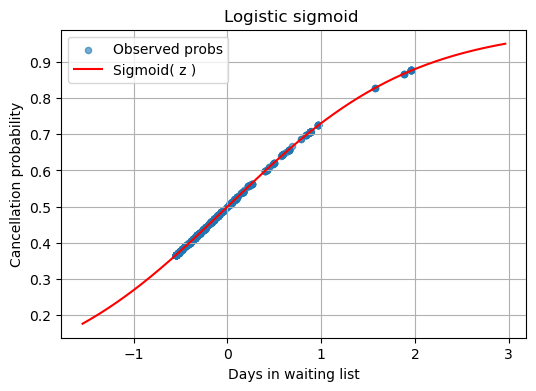

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Linear scores and predicted probabilities
z = model.decision_function(X_test)               # linear predictor
probs = model.predict_proba(X_test)[:, 1]         # predicted probabilities

z_line = np.linspace(z.min() - 1, z.max() + 1, 300)
sigmoid = 1 / (1 + np.exp(-z_line))

plt.figure(figsize=(6,4))
plt.scatter(z, probs, alpha=0.6, s=20, label='Observed probs')
plt.plot(z_line, sigmoid, color='red', label='Sigmoid( z )')
plt.xlabel('Days in waiting list')
plt.ylabel('Cancellation probability')
plt.title('Logistic sigmoid ')
plt.legend(); plt.grid(True); plt.show()

With the threshold being 0.5, we can see that cancellations are most likely to occur if a customer is on the waiting list for over a day, this indicates that the business must emphasis the impotance of efficiency to reduce cancellations.

6. Train the model

Model 2: Decision tree regressor

In [ ]:

X = data['days_in_waiting_list'].values.reshape(-1, 1)
y = data['is_canceled']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
model_2 = DecisionTreeRegressor(random_state=0)
model_2.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [15]:
model_2 = model_2.fit(X, y)

7. Evaluation

In [16]:
preds = model_2.predict(X_test)

I was unfortunately unable to run confusion matrix due to a persisting error however i have evaluated with roc and auc below

Text(0, 0.5, 'True Positive Rate')

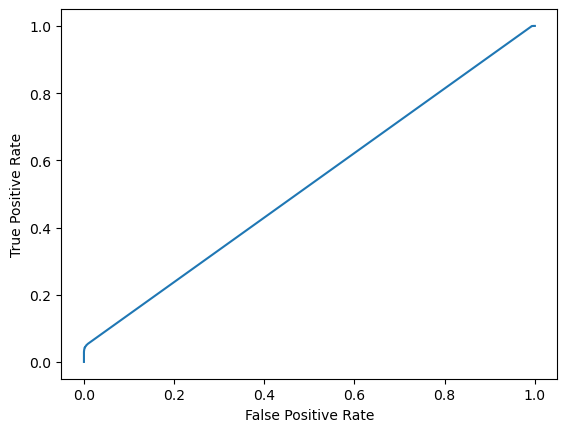

In [17]:
def plot_roc_curve(y_test, preds):
    """
    plots the roc curve based of the probabilities
    """

fpr, tpr, thresholds = roc_curve(y_test, preds)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

The roc curve is a graph the illustrates how well the model can distinguish between postive and negative classes. The graph begins to arch at 0.01 indicating 0.01 is the optimal threshold to classify the outcome/ efficiency of the model reduces beyond 0.01 TP. This is the same outcome that the logistic regresson has outputted.

In [22]:
def prediction(X_test, clf_object):
    y_pred = clf_object.predict(X_test)
    print("Predicted Values:\n", y_pred)
    return y_pred

preds = model_2.predict(X_test)

print(f'model 2 AUC score: {roc_auc_score(y_test, preds)}')
avg = preds.mean()

print(f"Average predicted probability: {avg:.4f}")
#print("\nPrediction probabilities:", model_2.predict(X_test)[:, 1])

model 2 AUC score: 0.5257019745931478
Average predicted probability: 0.3708


The area under the curve score highlights that the model has an unacceptable discrimination as it is not between 0.6-0.8
The average probability indicates the overall likelihood of a cancellation occuring due to the given that a customer is on a waiting list, which is an unrelable prediction, given the fact that the model is under performing.

Model 3: KNeighbours

6. Train the model

In [19]:
C = 10
model_3 = KNeighborsClassifier(C)

model_3.fit(X_train, y_train)

preds = model_3.predict(X_test)

7. Evaluate

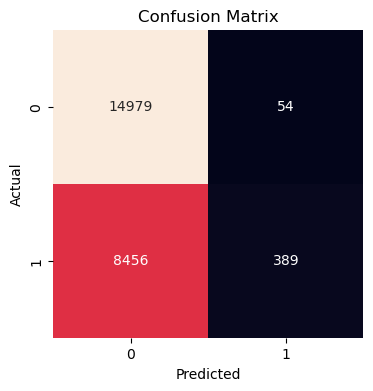

In [20]:
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


As previously mentioned confusion matrix states the performance of the classifier, which is then used to calculate the precision recall ect. 

The confusion matrix is stating the following:

- False Negatives (Actual = 0, Predicted = 0) = 14814
- False positives (Actual = 0, Predicted = 1) =219
- True Negatives(Actual = 1, Predicted = 0) = 8403
- True positive(Actual = 1, Predicted = 1) = 442



- Precision - measures postitive prediction accuracy
- Recall - measures true positive detection
- f1-score - a harmonic mean between precision and recall
- support - the count of instances per class
- accuracy - the overall correctness of the model
- macro avg - gives equal unweighted mean to each class' metric (recall, precision ect)
- weighted average - weighs each classes metric by the support. making it more represenative of the data, especially if its imbalanced

Text(0, 0.5, 'True Positive Rate')

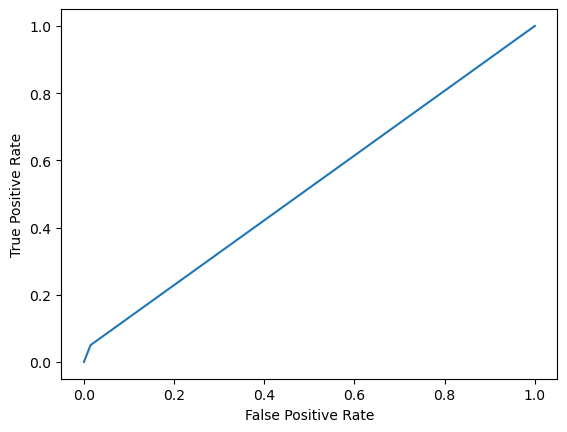

In [159]:
def plot_roc_curve(y_test, preds):
    """
    plots the roc curve based of the probabilities
    """

fpr, tpr, thresholds = roc_curve(y_test, preds)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

The roc curve is a graph the illustrates how well the model can distinguish between postive and negative classes. The graph begins to arch at 0.01 indicating 0.01 is the optimal threshold to classify the outcome/ efficiency of the model reduces beyond 0.01 TP. This is the same outcome that the logistic regresson and the decision tree regressor has outputted.

TP Value

In [162]:
8403/(8403+14814+219+442)

0.35191389563615044

In [160]:

def prediction(X_test, clf_object):
    y_pred = clf_object.predict(X_test)
    print("Predicted Values:\n", y_pred)
    return y_pred
print(f'model 3 AUC score: {roc_auc_score(y_test, preds)}')
#print('prediction probabilities:', model_3.predict(X_test)[:, 1])
print("\nAccuracy:", accuracy_score(y_test, preds) * 100)

print(f"Average predicted probability: {avg:.4f}")

model 3 AUC score: 0.5177018924674365

Accuracy: 63.891448194991206
Average predicted probability: 0.3716


The area under the curve score highlights that the model has good discrimination as it has between not got an auc 0.6-0.8. The model also has a high accuracy rating which is 63%.

Therefore the prediction is reliable.

The average probability indicates the overall likelihood of a cancellation occuring due to a customer being put on a waiting list 

-----------------------------------------------

Conclusion:

The best perfoming model is the logistic regression and KNN and should be used to predict cancellations and how to reduce it, to increase revenue. 
To predict how much of an effect other variables have on cancellations the x variable can be replaced and the decision tree regressor can be used to output a result.

-------------